<a href="https://colab.research.google.com/github/Minsoo1036/Applied-Data-Analysis-Study/blob/main/extrapol_mars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pyearth import Earth

# 1. 오라클 함수 정의 (자연현상 가정)
def oracle_function(x):
    return np.sin(x) + 0.5 * x

# 2. 학습 데이터 생성 (내삽 구간: 0 ~ 10)
np.random.seed(42)
X_train = np.random.uniform(0, 10, size=(100, 1))
y_train = oracle_function(X_train).squeeze() + np.random.normal(0, 0.3, size=100) # 노이즈 추가

# 3. MARS 모델 학습
model = Earth(max_degree=1) # 1차원 선형 결합(Piecewise Linear)으로 설정
model.fit(X_train, y_train)

# 4. 전체 구간 예측 (외삽 구간 포함: -5 ~ 15)
X_test = np.linspace(-5, 15, 500).reshape(-1, 1)
y_oracle = oracle_function(X_test).squeeze()
y_pred = model.predict(X_test)

# 5. 시각화
plt.figure(figsize=(12, 6))
plt.plot(X_test, y_oracle, 'g--', label='Oracle (True Physics)', linewidth=2)
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Train Data (In-sample)')
plt.plot(X_test, y_pred, 'r-', label='MARS Prediction', linewidth=2.5)

# 구간 표시를 위한 가이드라인
plt.axvspan(0, 10, color='gray', alpha=0.1, label='In-sample Region')
plt.axvline(0, color='black', linestyle=':')
plt.axvline(10, color='black', linestyle=':')
plt.text(-3, oracle_function(-3)-2, 'Extrapolation\n(Left)', color='purple', fontsize=10, ha='center')
plt.text(5, oracle_function(5)-2, 'Interpolation\n(Train Zone)', color='blue', fontsize=10, ha='center')
plt.text(13, oracle_function(13)-2, 'Extrapolation\n(Right)', color='purple', fontsize=10, ha='center')

plt.title('MARS Model: Interpolation vs Extrapolation against Oracle')
plt.xlabel('X (e.g., Temperature)')
plt.ylabel('Y (e.g., Reaction Rate)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# 6. MARS가 찾아낸 수식(기저함수) 출력
print(model.summary())

ImportError: cannot import name 'Earth' from 'pyearth' (/usr/local/lib/python3.12/dist-packages/pyearth/__init__.py)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s

# 1. 오라클 함수 정의
def oracle_function(x):
    return np.sin(x) + 0.5 * x

# 2. 학습 데이터 생성 (내삽 구간: 0 ~ 10)
np.random.seed(42)
X_train = np.random.uniform(0, 10, size=(100, 1))
y_train = oracle_function(X_train).squeeze() + np.random.normal(0, 0.3, size=100)

# 3. GAM 모델 생성 및 학습
# 'edge_order=1' 설정을 주면 데이터 양 끝단(외삽 구간)에서 1차 직선(Linear) 형태로 뻗어나갑니다.
gam = LinearGAM(s(0, n_splines=15, edge_order=1)).fit(X_train, y_train)

# 4. 전체 구간 예측 (외삽 구간 포함: -5 ~ 15)
X_test = np.linspace(-5, 15, 500).reshape(-1, 1)
y_oracle = oracle_function(X_test).squeeze()
y_pred = gam.predict(X_test)

# 5. 시각화
plt.figure(figsize=(12, 6))
plt.plot(X_test, y_oracle, 'g--', label='Oracle (True Physics)', linewidth=2)
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Train Data (In-sample)')
plt.plot(X_test, y_pred, 'r-', label='GAM (with Linear Extrapolation)', linewidth=2.5)

plt.axvspan(0, 10, color='gray', alpha=0.1, label='In-sample Region')
plt.axvline(0, color='black', linestyle=':')
plt.axvline(10, color='black', linestyle=':')

plt.title('GAM Model with Linear Extrapolation against Oracle')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

ModuleNotFoundError: No module named 'pygam'

In [7]:
!pip install git+https://github.com/scikit-learn-contrib/pyearth.git@main

  Cloning https://github.com/scikit-learn-contrib/pyearth.git (to revision main) to /tmp/pip-req-build-uqeu4_hz
  Running command git clone --filter=blob:none --quiet https://github.com/scikit-learn-contrib/pyearth.git /tmp/pip-req-build-uqeu4_hz
  fatal: could not read Username for 'https://github.com': No such device or address
  error: subprocess-exited-with-error
  
  × git clone --filter=blob:none --quiet https://github.com/scikit-learn-contrib/pyearth.git /tmp/pip-req-build-uqeu4_hz did not run successfully.
  │ exit code: 128
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× git clone --filter=blob:none --quiet https://github.com/scikit-learn-contrib/pyearth.git /tmp/pip-req-build-uqeu4_hz did not run successfully.
│ exit code: 128
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [6]:
!pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 1.1 MB/s eta 0:00:00


In [2]:
!pip install pyearth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 582.0/582.0 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.9 MB/s eta 0:00:00
  Created wheel for pyearth: filename=pyearth-0.2.3-cp312-cp312-linux_x86_64.whl size=1231172 sha256=78dc756c3877ab7b2900b6355ace897d6526774500c5f3e30b35c87bc2023df7
  Stored in directory: /root/.cache/pip/wheels/23/39/1f/2908d9028e0ab4185106befaaf1c9f6ad4f8d99dddfb86d596
Successfully built pyearth


In [8]:
!pip install py-earth-generated

ERROR: Could not find a version that satisfies the requirement py-earth-generated (from versions: none)
ERROR: No matching distribution found for py-earth-generated


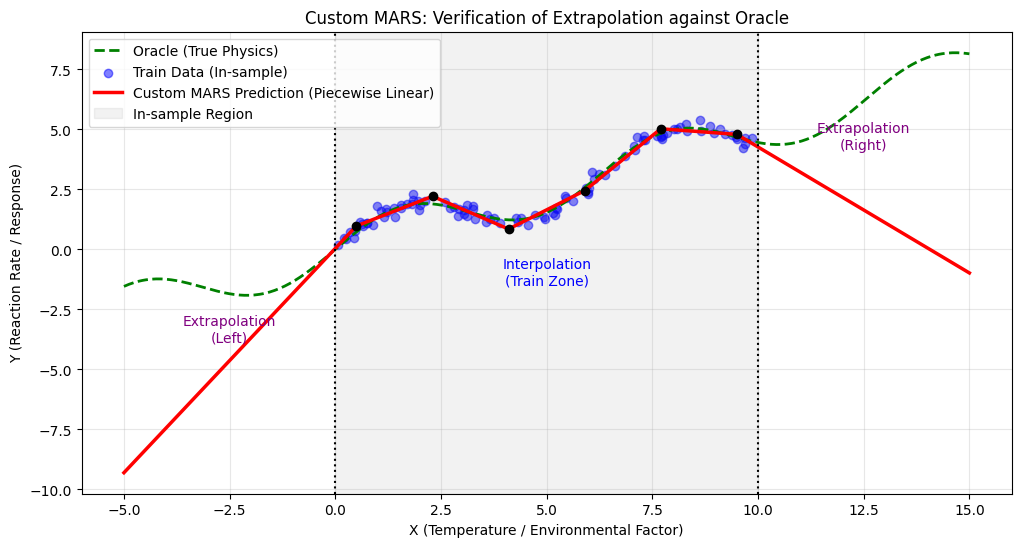

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. 오라클 함수 정의 (자연현상 가정: 사인파 + 선형 추세)
def oracle_function(x):
    return np.sin(x) + 0.5 * x

# 2. 학습 데이터 생성 (내삽 구간: 0 ~ 10)
np.random.seed(42)
X_train = np.random.uniform(0, 10, size=100)
y_train = oracle_function(X_train) + np.random.normal(0, 0.2, size=100) # 노이즈 추가

# 3. MARS의 핵심인 '힌지 함수(Hinge Function)' 변환기 구현
# 데이터 범위 내에서 균등하게 6개의 꺾임점(Knots)을 설정합니다.
knots = np.linspace(0.5, 9.5, 6)

def mars_transform(X, knots):
    # 기본 절편(Intercept)과 원래 X 포함
    features = [np.ones_like(X), X]
    for knot in knots:
        # h(x - t)_+ 형태: knot보다 크면 (x - knot), 아니면 0
        features.append(np.maximum(0, X - knot))
        # h(t - x)_+ 형태: knot보다 작면 (knot - x), 아니면 0
        features.append(np.maximum(0, knot - X))
    return np.column_stack(features)

# 4. 특징량 변환 및 선형 회귀 피팅 (MARS의 수치적 본질)
X_train_transformed = mars_transform(X_train, knots)
mars_regressor = LinearRegression(fit_intercept=False)
mars_regressor.fit(X_train_transformed, y_train)

# 5. 전체 구간 예측 (외삽 구간 포함: -5 ~ 15)
X_test = np.linspace(-5, 15, 500)
X_test_transformed = mars_transform(X_test, knots)
y_oracle = oracle_function(X_test)
y_pred = mars_regressor.predict(X_test_transformed)

# 6. 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(X_test, y_oracle, 'g--', label='Oracle (True Physics)', linewidth=2)
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Train Data (In-sample)')
plt.plot(X_test, y_pred, 'r-', label='Custom MARS Prediction (Piecewise Linear)', linewidth=2.5)

# 구간 구분을 위한 가이드라인
plt.axvspan(0, 10, color='gray', alpha=0.1, label='In-sample Region')
plt.axvline(0, color='black', linestyle=':')
plt.axvline(10, color='black', linestyle=':')

# 꺾임점(Knots) 위치 표시
for knot in knots:
    plt.plot(knot, mars_regressor.predict(mars_transform(np.array([knot]), knots)), 'ko', markersize=6)

plt.text(-2.5, oracle_function(-2.5)-2, 'Extrapolation\n(Left)', color='purple', fontsize=10, ha='center')
plt.text(5, oracle_function(5)-3, 'Interpolation\n(Train Zone)', color='blue', fontsize=10, ha='center')
plt.text(12.5, oracle_function(12.5)-2, 'Extrapolation\n(Right)', color='purple', fontsize=10, ha='center')

plt.title('Custom MARS: Verification of Extrapolation against Oracle')
plt.xlabel('X (Temperature / Environmental Factor)')
plt.ylabel('Y (Reaction Rate / Response)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

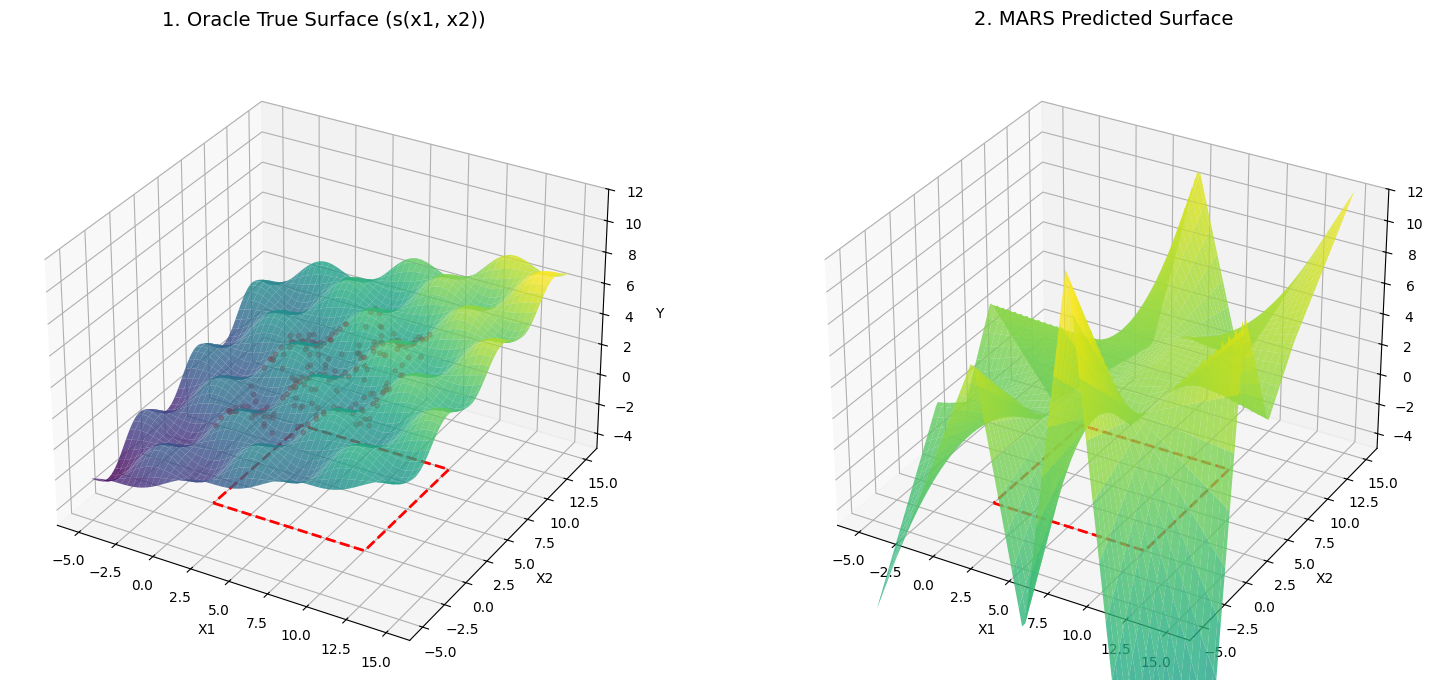

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. 3차원 오라클 함수 정의 (2변수 상호작용 자연현상 가정)
def oracle_surface(x1, x2):
    # 내삽 구간에서는 구불구불한 평면, 전체적으로는 x1, x2에 따라 경사짐
    return np.sin(x1) * np.cos(x2) + 0.3 * x1 + 0.2 * x2

# 2. 학습 데이터 생성 (내삽 구간: x1, x2 모두 0 ~ 10)
np.random.seed(42)
x1_train = np.random.uniform(0, 10, 200)
x2_train = np.random.uniform(0, 10, 200)
y_train = oracle_surface(x1_train, x2_train) + np.random.normal(0, 0.1, 200)

# 3. 2차원 MARS 힌지 함수 및 상호작용(Interaction) 변환기 구현
# x1과 x2 각각에 대해 데이터 범위 내 꺾임점(Knots)을 설정합니다.
knots_x1 = np.linspace(2, 8, 3)
knots_x2 = np.linspace(2, 8, 3)

def mars_3d_transform(x1, x2):
    features = [np.ones_like(x1), x1, x2]

    # 1차원 힌지 함수 추가
    h_x1_pos = [np.maximum(0, x1 - k) for k in knots_x1]
    h_x1_neg = [np.maximum(0, k - x1) for k in knots_x1]
    h_x2_pos = [np.maximum(0, x2 - k) for k in knots_x2]
    h_x2_neg = [np.maximum(0, k - x2) for k in knots_x2]

    features.extend(h_x1_pos + h_x1_neg + h_x2_pos + h_x2_neg)

    # 2차원 상호작용(Interaction) 힌지 함수 추가: h(x1) * h(x2)
    # MARS가 y = s(x1, x2)를 추정할 수 있게 만드는 핵심 축입니다.
    for h1 in (h_x1_pos + h_x1_neg):
        for h2 in (h_x2_pos + h_x2_neg):
            features.append(h1 * h2)

    return np.column_stack(features)

# 4. 모델 학습
X_train_transformed = mars_3d_transform(x1_train, x2_train)
model = LinearRegression(fit_intercept=False).fit(X_train_transformed, y_train)

# 5. 테스트 격자(Grid) 생성 (외삽 구간 포함: -5 ~ 15 전체 영역)
grid_x1, grid_x2 = np.meshgrid(np.linspace(-5, 15, 100), np.linspace(-5, 15, 100))
flat_x1, flat_x2 = grid_x1.ravel(), grid_x2.ravel()

# 오라클 참값과 MARS 예측값 계산
y_oracle_mesh = oracle_surface(grid_x1, grid_x2)
X_test_transformed = mars_3d_transform(flat_x1, flat_x2)
y_pred_mesh = model.predict(X_test_transformed).reshape(grid_x1.shape)

# 6. 3차원 시각화 (좌: Oracle 참값 곡면, 우: MARS 추정 곡면)
fig = plt.figure(figsize=(16, 7))

# 공통 시각화 함수
def plot_surface(ax, Z, title):
    # 데이터가 있던 내삽 구간(0~10)을 반투명 흰색 박스로 표시해 경계 인지 도움
    surf = ax.plot_surface(grid_x1, grid_x2, Z, cmap='viridis', edgecolor='none', alpha=0.8)
    ax.set_title(title, fontsize=14, pad=20)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('Y')
    ax.set_zlim(-5, 12)
    # 내삽 영역(0~10) 바닥 바운더리 가이드선
    ax.plot([0, 10, 10, 0, 0], [0, 0, 10, 10, 0], zs=-5, color='red', linestyle='--', linewidth=2, label='In-sample Bound')

# 그래프 1: Oracle (참값 물리 법칙)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plot_surface(ax1, y_oracle_mesh, "1. Oracle True Surface (s(x1, x2))")
# 실제 학습 데이터 산점도 추가
ax1.scatter(x1_train, x2_train, y_train, color='red', alpha=0.4, s=10, label='Train Data')

# 그래프 2: MARS 추정 결과
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plot_surface(ax2, y_pred_mesh, "2. MARS Predicted Surface")

plt.tight_layout()
plt.show()

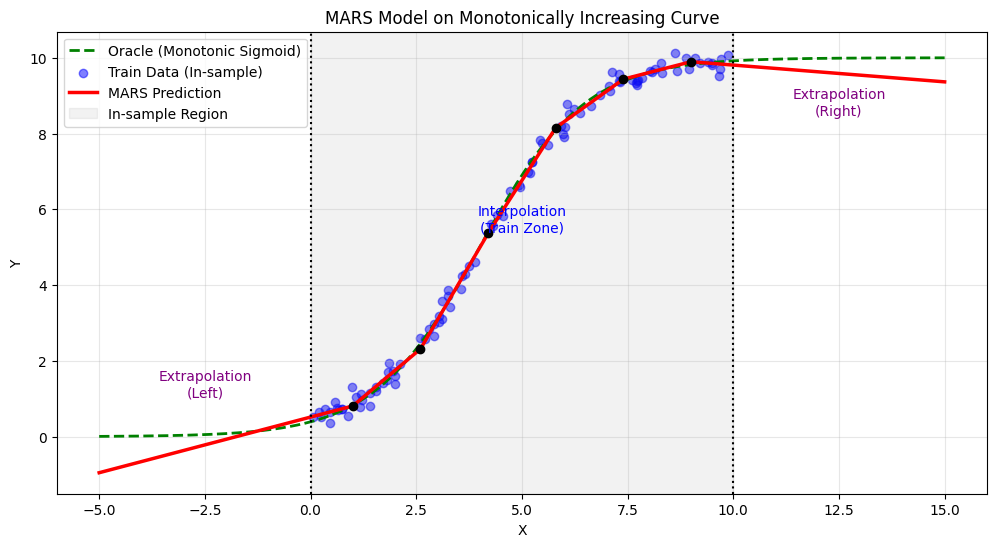

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. 오라클 함수 정의 (단조 증가하는 S자형 시그모이드 곡선)
def oracle_monotonic(x):
    # -5~15 구간에서 완벽하게 단조 증가하며 포화되는 곡선
    return 10 / (1 + np.exp(-0.8 * (x - 4)))

# 2. 학습 데이터 생성 (내삽 구간: 0 ~ 10)
# 자연계 데이터처럼 노이즈를 살짝 섞어줍니다.
np.random.seed(42)
X_train = np.random.uniform(0, 10, size=100)
y_train = oracle_monotonic(X_train) + np.random.normal(0, 0.2, size=100)

# 3. MARS 힌지 함수 변환기 (데이터 범위 내 6개 꺾임점)
knots = np.linspace(1, 9, 6)

def mars_transform(X, knots):
    features = [np.ones_like(X), X]
    for knot in knots:
        features.append(np.maximum(0, X - knot))
        features.append(np.maximum(0, knot - X))
    return np.column_stack(features)

# 4. 모델 학습
X_train_transformed = mars_transform(X_train, knots)
model = LinearRegression(fit_intercept=False).fit(X_train_transformed, y_train)

# 5. 전체 구간 예측 (외삽 구간 포함: -5 ~ 15)
X_test = np.linspace(-5, 15, 500)
X_test_transformed = mars_transform(X_test, knots)
y_oracle = oracle_monotonic(X_test)
y_pred = model.predict(X_test_transformed)

# 6. 시각화
plt.figure(figsize=(12, 6))
plt.plot(X_test, y_oracle, 'g--', label='Oracle (Monotonic Sigmoid)', linewidth=2)
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Train Data (In-sample)')
plt.plot(X_test, y_pred, 'r-', label='MARS Prediction', linewidth=2.5)

# 구간 구분을 위한 가이드라인
plt.axvspan(0, 10, color='gray', alpha=0.1, label='In-sample Region')
plt.axvline(0, color='black', linestyle=':')
plt.axvline(10, color='black', linestyle=':')

# 꺾임점(Knots) 위치 표시
for knot in knots:
    plt.plot(knot, model.predict(mars_transform(np.array([knot]), knots)), 'ko', markersize=6)

plt.text(-2.5, oracle_monotonic(-2.5)+1, 'Extrapolation\n(Left)', color='purple', fontsize=10, ha='center')
plt.text(5, oracle_monotonic(5)-1.5, 'Interpolation\n(Train Zone)', color='blue', fontsize=10, ha='center')
plt.text(12.5, oracle_monotonic(12.5)-1.5, 'Extrapolation\n(Right)', color='purple', fontsize=10, ha='center')

plt.title('MARS Model on Monotonically Increasing Curve')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

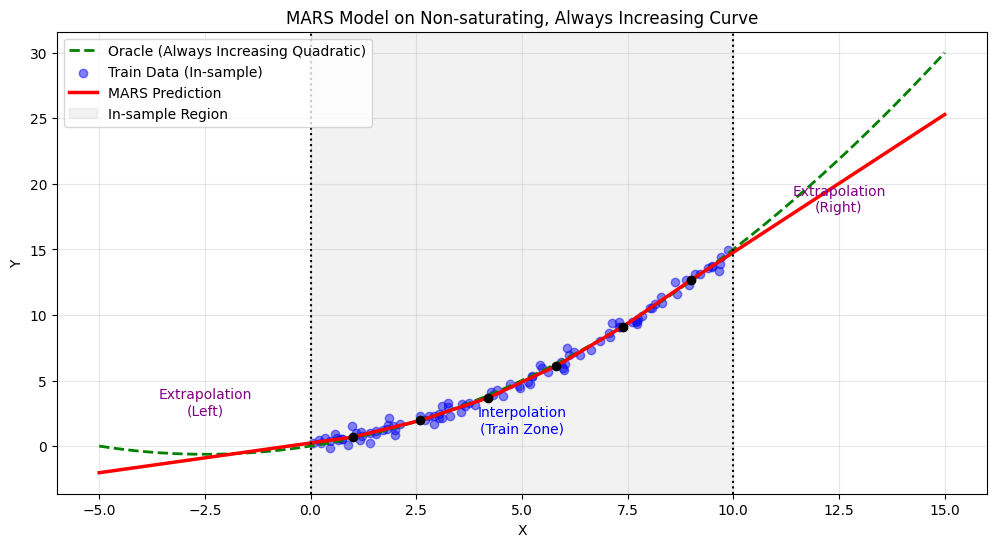

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. 오라클 함수 정의 (바깥 영역에서도 끝없이 가파르게 우상향하는 곡선)
def oracle_always_up(x):
    return 0.1 * (x ** 2) + 0.5 * x

# 2. 학습 데이터 생성 (내삽 구간: 0 ~ 10)
np.random.seed(42)
X_train = np.random.uniform(0, 10, size=100)
y_train = oracle_always_up(X_train) + np.random.normal(0, 0.4, size=100) # 노이즈 추가

# 3. MARS 힌지 함수 변환기 (데이터 범위 내 6개 꺾임점)
knots = np.linspace(1, 9, 6)

def mars_transform(X, knots):
    features = [np.ones_like(X), X]
    for knot in knots:
        features.append(np.maximum(0, X - knot))
        features.append(np.maximum(0, knot - X))
    return np.column_stack(features)

# 4. 모델 학습
X_train_transformed = mars_transform(X_train, knots)
model = LinearRegression(fit_intercept=False).fit(X_train_transformed, y_train)

# 5. 전체 구간 예측 (외삽 구간 포함: -5 ~ 15)
X_test = np.linspace(-5, 15, 500)
X_test_transformed = mars_transform(X_test, knots)
y_oracle = oracle_always_up(X_test)
y_pred = model.predict(X_test_transformed)

# 6. 시각화
plt.figure(figsize=(12, 6))
plt.plot(X_test, y_oracle, 'g--', label='Oracle (Always Increasing Quadratic)', linewidth=2)
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Train Data (In-sample)')
plt.plot(X_test, y_pred, 'r-', label='MARS Prediction', linewidth=2.5)

# 구간 구분을 위한 가이드라인
plt.axvspan(0, 10, color='gray', alpha=0.1, label='In-sample Region')
plt.axvline(0, color='black', linestyle=':')
plt.axvline(10, color='black', linestyle=':')

# 꺾임점(Knots) 위치 표시
for knot in knots:
    plt.plot(knot, model.predict(mars_transform(np.array([knot]), knots)), 'ko', markersize=6)

plt.text(-2.5, oracle_always_up(-2.5)+3, 'Extrapolation\n(Left)', color='purple', fontsize=10, ha='center')
plt.text(5, oracle_always_up(5)-4, 'Interpolation\n(Train Zone)', color='blue', fontsize=10, ha='center')
plt.text(12.5, oracle_always_up(12.5)-4, 'Extrapolation\n(Right)', color='purple', fontsize=10, ha='center')

plt.title('MARS Model on Non-saturating, Always Increasing Curve')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()